In [1]:
import pandas as pd
import numpy as np

In [2]:
def safe_convert(col):
    col_cleaned = col.replace(',', '', regex=True)
    return pd.to_numeric(col_cleaned, errors='coerce')

setpt = pd.read_csv('setpoint_publish(in).csv')
setpt = setpt.apply(lambda col: safe_convert(col) if col.name != 'var' else col)
setpt.columns = setpt.columns.str.strip() #delete whitespace in csv file
setpt

,var,opt_mean,opt_sig,drift_mean,drift_sig,excursion_mean,excursion_sig
0,x1,22.1,0.295,22.111,0.442,22.115,0.5900
1,x2,44.8,1.045,46.010,1.840,46.547,2.3270
2,x4,0.4,0.023,0.368,0.027,0.304,0.0670
3,x5,150000.0,8000.000,135000.000,9000.000,120000.000,16000.0000
4,x7,1206.0,48.240,1266.300,75.978,1266.300,88.6410
5,x8,87.0,5.220,91.176,6.686,107.880,12.2264
6,x9,454.0,19.673,456.270,22.814,599.280,69.9160
7,x17,5492.0,256.293,5526.050,349.983,5552.410,425.6850
8,x3,NaN,NaN,39.000,2.860,NaN,NaN
9,x6,NaN,NaN,112.000,6.720,NaN,NaN


In [3]:
number_of_wafers = 5000

def generate_normal_data(mean, std_dev, size=number_of_wafers, seed=None):
    return np.random.normal(loc=mean, scale=std_dev, size=size)

In [4]:
from scipy.stats import skewnorm

def generate_skewed_data(mean, sig, alpha, size=number_of_wafers):
    return skewnorm.rvs(a=alpha, loc=mean, scale=sig, size=number_of_wafers)

In [5]:
datasets = {}
for data_name in ["opt", "drift", "excursion"]:
    rows = []
    for var, mean, sig in zip(setpt['var'], setpt[f'{data_name}_mean'], setpt[f'{data_name}_sig']):
        if data_name=="excursion" and var in ["x4","x5"]:
            rows.append(generate_skewed_data(mean, sig, alpha=200))
        elif data_name=="excursion" and var=="x8":
            rows.append(generate_skewed_data(mean, sig, alpha=-100))
        elif data_name=="excursion" and var=="x9":
            rows.append(generate_skewed_data(mean, sig, alpha=-200))
        else:
            rows.append(generate_normal_data(mean, sig, seed=42))
    
    datasets[data_name] = pd.DataFrame(np.column_stack(rows), columns=setpt['var'])

In [6]:
opt_data = datasets['opt']
drift_data = datasets['drift']
exc_data = datasets['excursion']

# Outcome 

In [7]:
#function from first task sheet
#opt_data['outcome'] = -( 4 * np.pi * opt_data['x1'] + (77 / 100) * (opt_data['x2'] ** 2) +
#   58 * opt_data['x5'] * opt_data['x4'] - 890 * opt_data['x17'] + 33.5 * opt_data['x7'] ) / (8 * 10**5)

opt_data['outcome'] = (-( 5 * np.pi * 10**4 * opt_data['x1'] + 770 * (opt_data['x2'] ** 2) +
    58 * opt_data['x5'] * opt_data['x4'] - 890 * opt_data['x17'] + 730.5 * opt_data['x7'] ) / (8 * 10**5) + 7.5)

#function from first task sheet
#drift_data['outcome'] = (-( 4 * np.pi * drift_data['x1'] + (77 / 100) * (drift_data['x2'] ** 2) +
#    58 * drift_data['x5'] * drift_data['x4'] - 890 * drift_data['x17'] + 33.5 * drift_data['x7'] ) / (8 * 10**5)) 
#+ (19 * drift_data['x5'] * drift_data['x9'] * drift_data['x8'] / (10**11))

drift_data['outcome'] = (-( 5 * np.pi * 10**4 * drift_data['x1'] + 770 * (drift_data['x2'] ** 2) +
    58 * drift_data['x5'] * drift_data['x4'] - 890 * drift_data['x17'] + 730.5 * drift_data['x7'] ) / (8 * 10**5) 
    + (39 * drift_data['x5'] * drift_data['x9'] * drift_data['x8']) / (10**11) + 7) 

#function from first task sheet
#exc_data['outcome'] = (-( 4 * np.pi * exc_data['x1'] + (77 / 100) * (exc_data['x2'] ** 2) +
#    58 * exc_data['x5'] * exc_data['x4'] - 890 * exc_data['x17'] + 33.5 * exc_data['x7'] ) / (8 * 10**5)) 
#+ ((19 * exc_data['x5'] * exc_data['x9'] * exc_data['x8']) / (10**11)) 
#+ ((0.8 * exc_data['x4'] * (exc_data['x5']**2) * exc_data['x17'] ) / (10**13))

exc_data['outcome'] = (-( 5 * np.pi * 10**4 * exc_data['x1'] + 770 * (exc_data['x2'] ** 2) +
    58 * exc_data['x5'] * exc_data['x4'] - 890 * exc_data['x17'] + 730.5 * exc_data['x7'] ) / (8 * 10**5) 
    + (39 * exc_data['x5'] * exc_data['x9'] * exc_data['x8']) / (10**11) + 7 
    + ((0.8 * exc_data['x4'] * (exc_data['x5'])**2 * exc_data['x17'] ) / (10**13)))


In [8]:
opt_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,x3,x6,x10,x11,x12,x13,x14,x15,x16,x18,x19,outcome
0,22.288421,44.456664,0.409543,147469.504931,1177.100867,81.132095,496.078698,5432.347669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.811401
1,22.409433,45.430211,0.367265,142079.458703,1173.372570,92.422539,439.869236,5121.740556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.956804
2,22.110410,45.208246,0.383872,160307.177342,1203.992989,85.267727,449.779839,5577.465187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.835562
3,22.004686,46.825622,0.406039,151646.205982,1219.753467,96.364714,449.972677,5141.236568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.210682
4,22.798438,44.308027,0.363654,146299.397103,1128.898230,79.254053,450.022334,5443.053768,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.301360


In [9]:
drift_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,x3,x6,x10,x11,x12,x13,x14,x15,x16,x18,x19,outcome
0,21.692825,45.230477,0.369907,129510.375030,1181.746023,89.102257,455.382307,5765.481799,37.829140,107.259501,558.525115,8.293479,13697.335394,331.620402,7517.365885,27.586598,630.357474,139936.762073,6247.229228,4.682758
1,22.019276,48.021984,0.357110,152988.625726,1357.997142,85.373299,443.687585,5762.883425,36.534845,119.497443,572.309373,8.132940,13925.249419,302.974963,8747.168654,28.198967,674.750118,134314.581087,6596.605862,3.927214
2,22.619024,47.134672,0.383141,124565.112248,1340.065858,89.135181,433.491579,5463.512623,34.269194,118.327713,542.509612,7.930786,14902.970377,324.631352,9306.483808,25.696476,637.813226,111817.986688,7045.537612,3.691891
3,21.684370,46.893127,0.389143,135938.459049,1342.656502,87.446635,474.618126,5491.869432,37.989569,116.363768,541.441759,8.302683,14674.043743,356.532121,9197.211403,28.240268,646.804633,128413.491208,6331.276764,3.874622
4,21.236916,47.880174,0.383206,118908.791968,1140.673507,89.128108,424.666922,4907.204645,42.064770,103.823895,562.649366,7.757080,15064.865234,333.262213,8487.113995,27.200348,639.868744,127500.026749,5989.164363,3.492974


In [10]:
exc_data.head()

var,x1,x2,x4,x5,x7,x8,x9,x17,x3,x6,x10,x11,x12,x13,x14,x15,x16,x18,x19,outcome
0,23.366426,51.200292,0.345049,124025.129336,1096.533585,88.895594,525.604042,6364.033888,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.827201
1,22.026904,48.464113,0.324691,120435.212690,1230.441676,105.554178,517.921424,4659.578391,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.962845
2,22.593387,46.578666,0.318857,128180.000222,1261.644761,88.596222,503.658101,4138.035351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.928914
3,22.356368,49.383807,0.315857,133922.327181,1296.665753,85.810179,559.008796,5689.125307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.425072
4,22.597515,46.217668,0.395478,129600.224058,1418.713839,105.490910,544.623773,5460.914728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.376753


In [11]:
opt_data.to_csv("data/opt_data.csv", index=None)
drift_data.to_csv("data/drift_data.csv", index=None)
exc_data.to_csv("data/excursion_data.csv", index=None)

# Visualize Kernel Density Plot

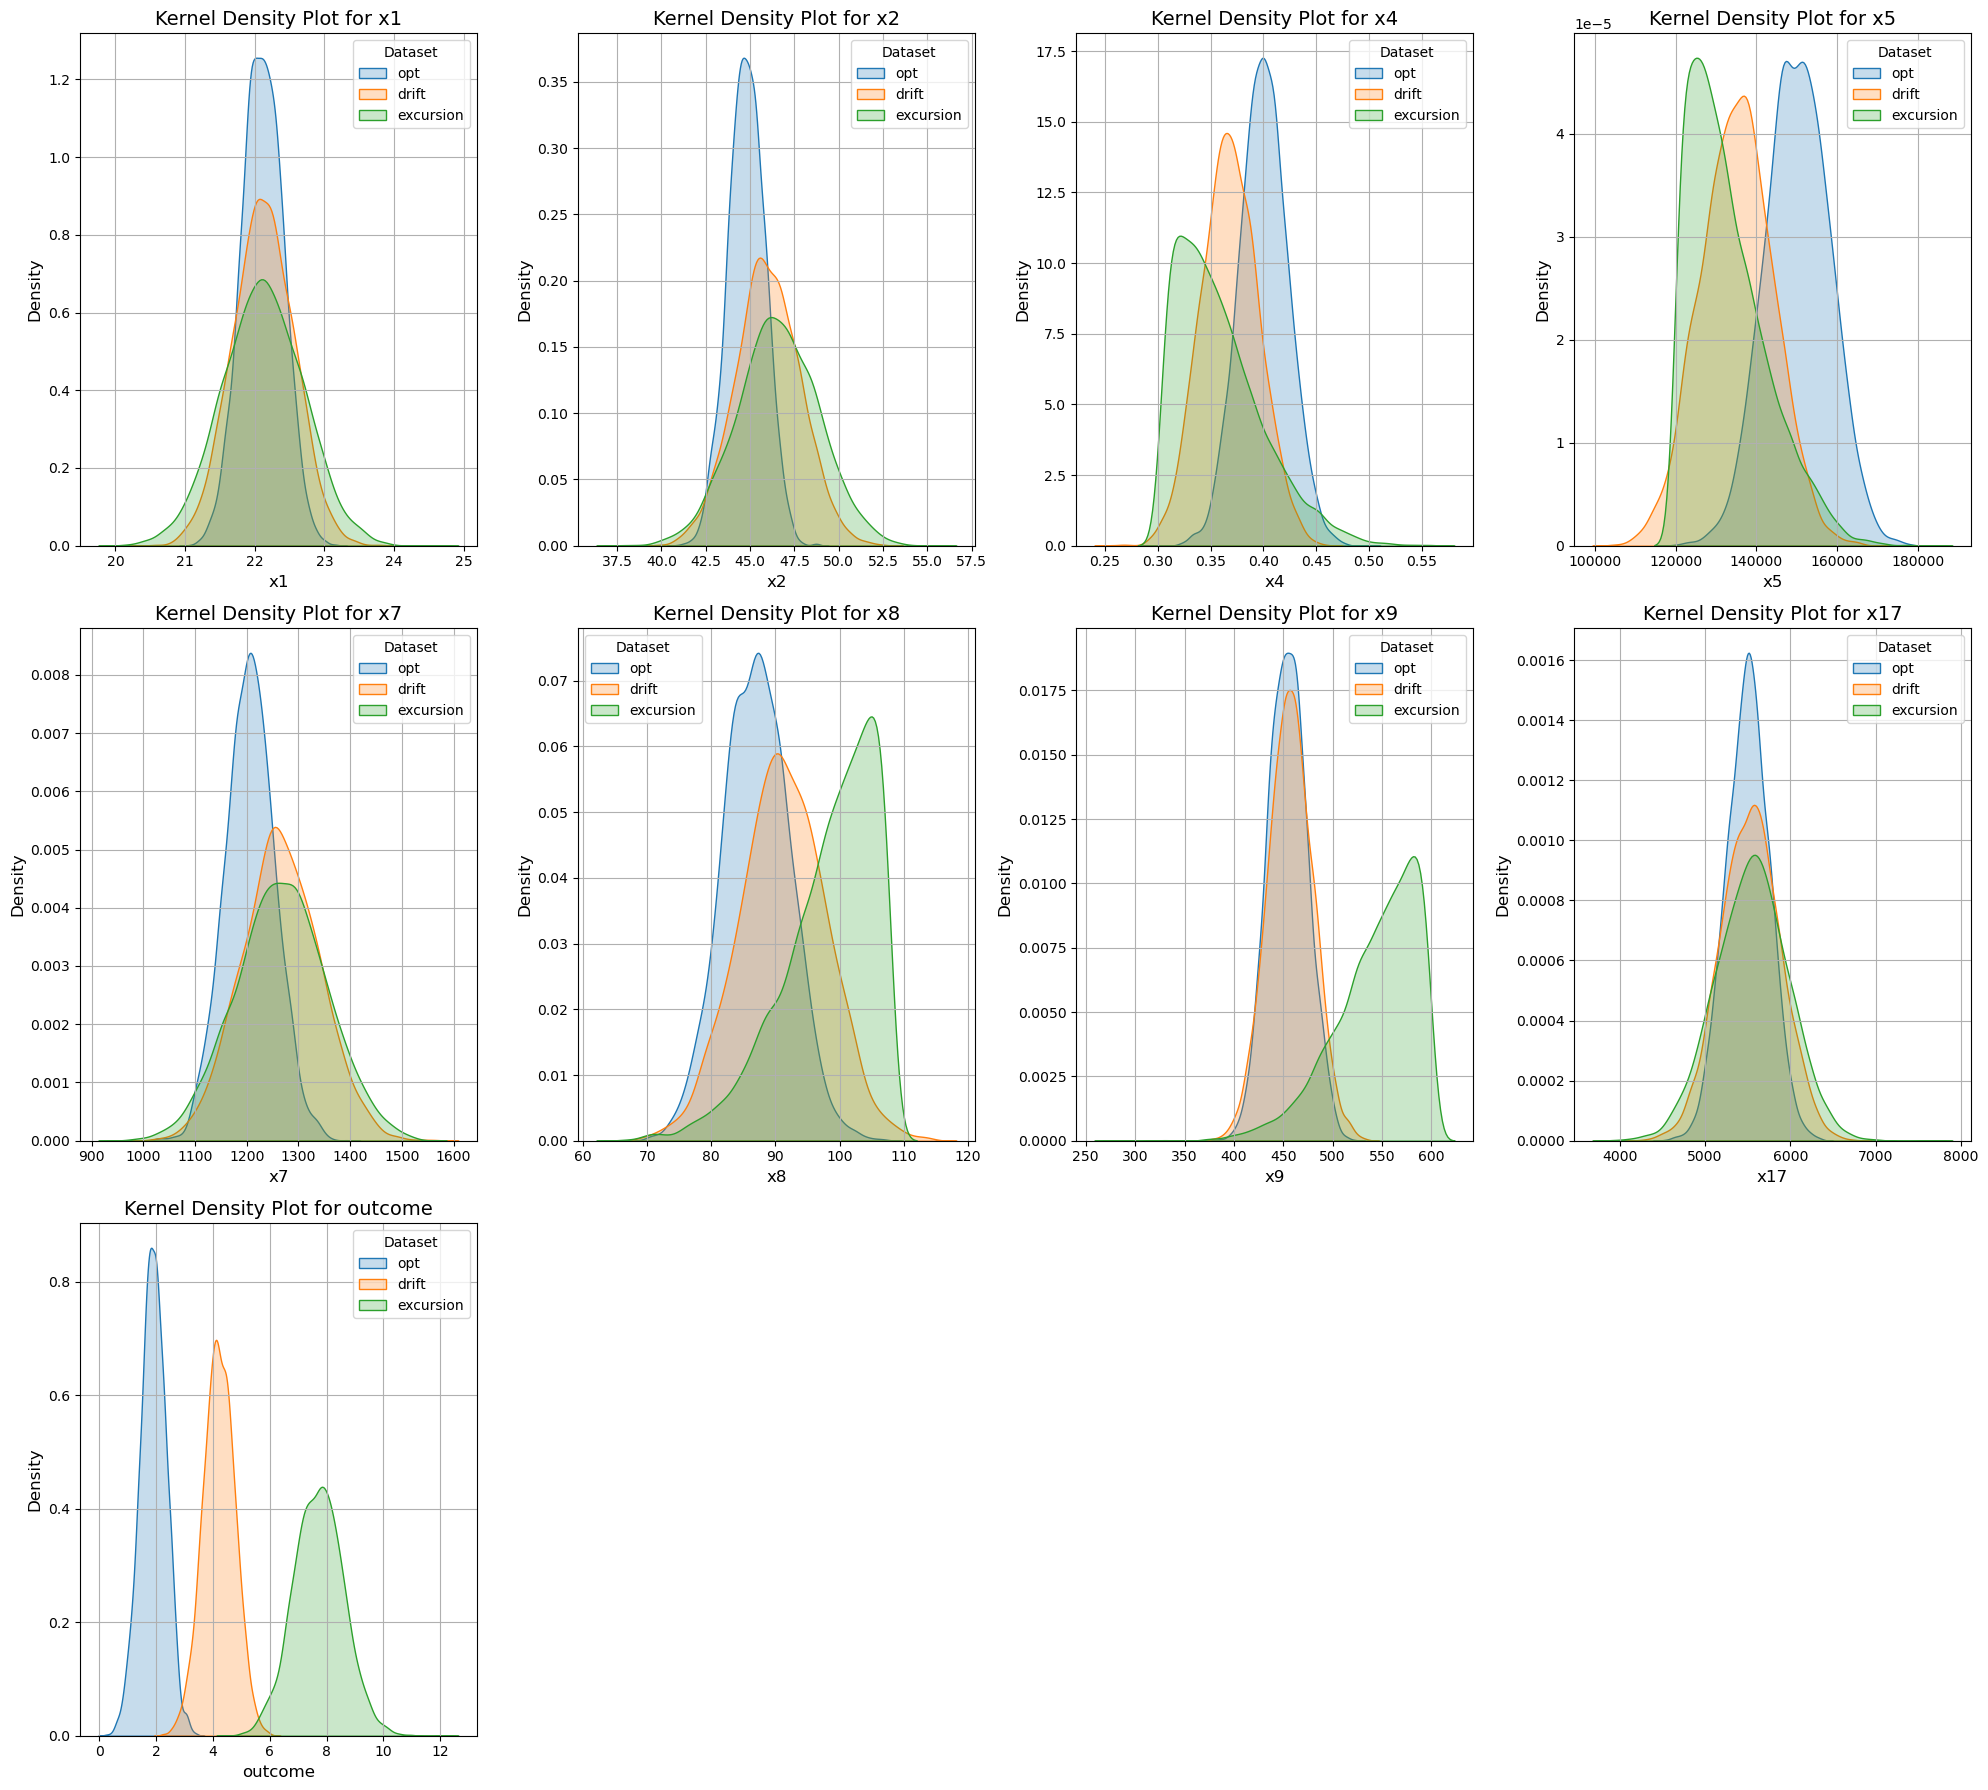

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

datasets = {
    'opt': opt_data,
    'drift': drift_data,
    'excursion': exc_data
}

variables = opt_data.columns.drop([' x3 ', ' x6 ',' x10 ', ' x11 ', ' x12 ', ' x13 ', ' x14 ', ' x15 ', ' x16 ', ' x18 ',' x19 '])

plots_per_row = 4

num_variables = len(variables)
num_rows = (num_variables + plots_per_row - 1) // plots_per_row 

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(20, 6 * num_rows))
axes = axes.flatten()  

for i, variable in enumerate(variables):
    ax = axes[i]
    for name, df in datasets.items():
        sns.kdeplot(df[variable], label=name, fill=True, ax=ax)
    ax.set_title(f'Kernel Density Plot for {variable}', fontsize=14)
    ax.set_xlabel(variable, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend(title='Dataset')
    ax.grid(True)

for j in range(len(variables), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Sanity Check
Correlation

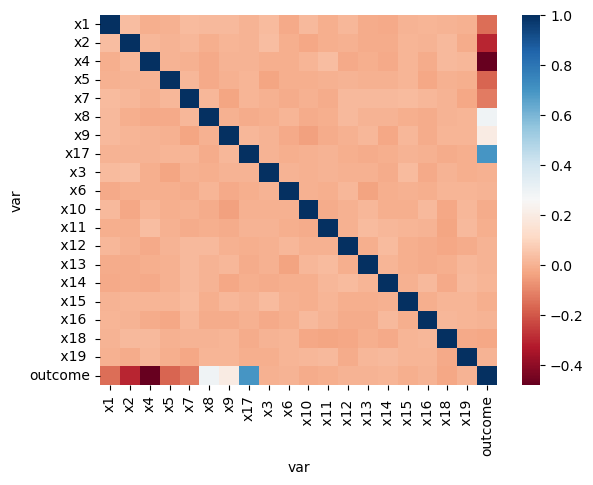

In [13]:
corr = drift_data.corr()

sns.heatmap(corr, 
            cmap='RdBu', 
            xticklabels=corr.columns.values,
            yticklabels=corr.columns.values)
plt.show()

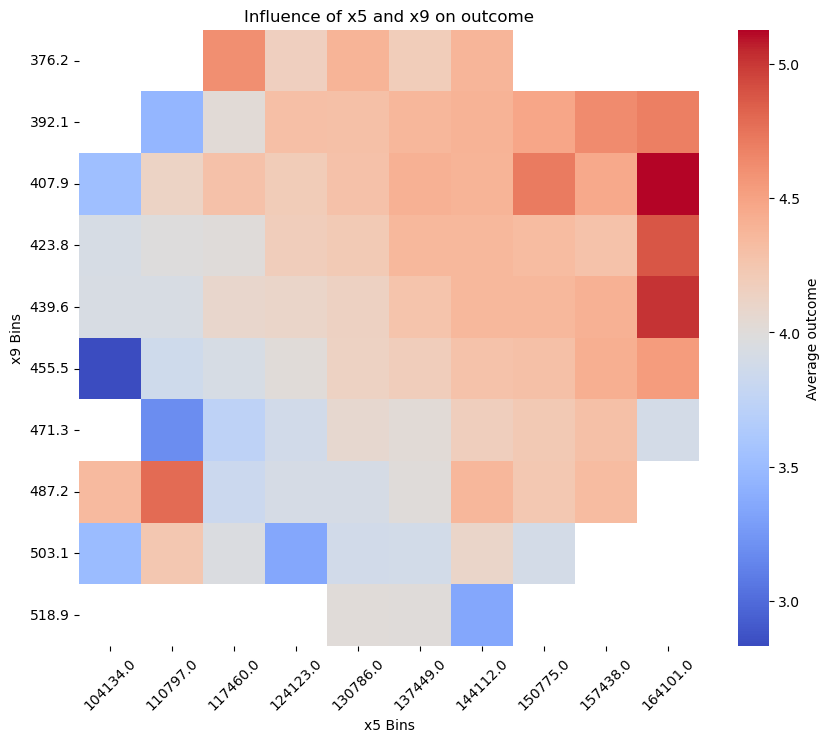

In [18]:
# Create a DataFrame
data = drift_data.copy()

# Define the number of bins for x and y
n_bins = 10
x_bins = np.linspace(data["x5"].min(), data["x5"].max(), n_bins + 1)
y_bins = np.linspace(data["x9"].min(), data["x9"].max(), n_bins + 1)

# Categorize x and y into bins
data['x5_bin'] = pd.cut(data['x5'], bins=x_bins, labels=False, include_lowest=True)
data['x9_bin'] = pd.cut(data['x9'], bins=y_bins, labels=False, include_lowest=True)

# Compute the average outcome value for each bin pair
heatmap_data = data.groupby(['x5_bin', 'x9_bin'])['outcome'].mean().unstack()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Average outcome'})
plt.title("Influence of x5 and x9 on outcome")
plt.xlabel("x5 Bins")
plt.ylabel("x9 Bins")
plt.xticks(ticks=np.arange(len(x_bins) - 1) + 0.5, labels=[f"{x_bins[i]:.1f}" for i in range(len(x_bins) - 1)], rotation=45)
plt.yticks(ticks=np.arange(len(y_bins) - 1) + 0.5, labels=[f"{y_bins[i]:.1f}" for i in range(len(y_bins) - 1)], rotation=0)
plt.show()


# ML Model 1: Random Forest

decision trees are built right up front,
explanation: https://www.youtube.com/watch?v=v6VJ2RO66Ag

   Feature  Importance
7      x17    0.495529
2       x4    0.222583
5       x8    0.080782
1       x2    0.079860
6       x9    0.026087
3       x5    0.022910
0       x1    0.015305
4       x7    0.011594
16    x16     0.004340
9      x6     0.004293
8      x3     0.004246
13    x13     0.004204
12    x12     0.004106
15    x15     0.004105
18    x19     0.004063
14    x14     0.004062
11    x11     0.004041
10    x10     0.003949
17    x18     0.003940


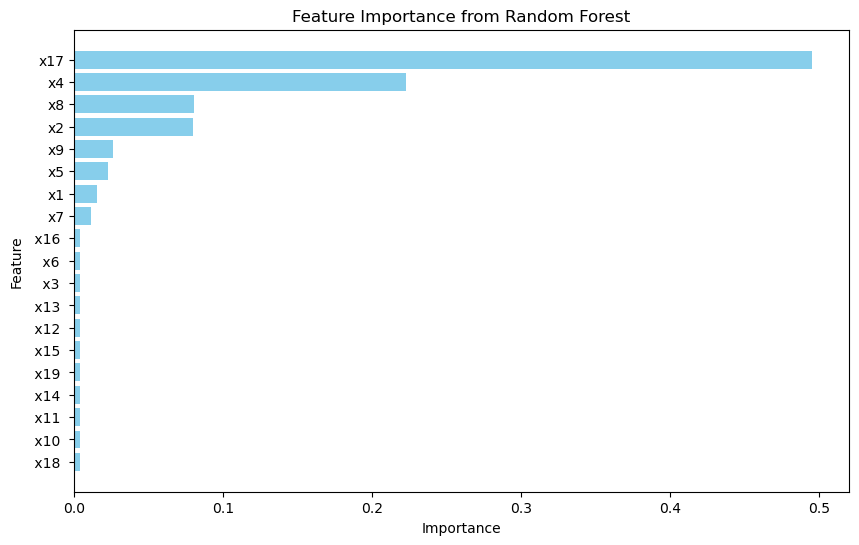

In [16]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = drift_data.drop(['outcome'],axis=1)
y = drift_data['outcome']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display feature importances
print(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.show()


## ML Model 2: XGB Regressor

decision trees are built one after another, each tree is built on reducing the loss of the previous one, explanation: https://www.youtube.com/watch?v=uV2gdNt2MLc

   Feature  Importance
7      x17    0.513407
2       x4    0.194378
5       x8    0.094228
1       x2    0.074382
6       x9    0.040735
3       x5    0.031944
4       x7    0.020505
0       x1    0.015071
12    x12     0.001837
16    x16     0.001825
15    x15     0.001730
13    x13     0.001515
17    x18     0.001372
11    x11     0.001280
14    x14     0.001275
9      x6     0.001256
10    x10     0.001225
18    x19     0.001027
8      x3     0.001007


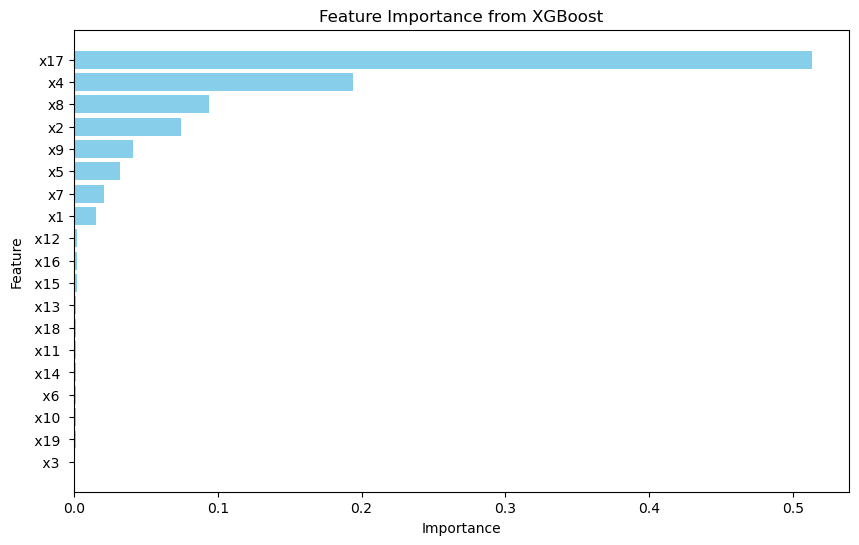

In [17]:
import numpy as np
import pandas as pd
#%pip install xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = drift_data.drop(['outcome'],axis=1)
y = drift_data['outcome']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train an XGBoost model
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display feature importances
print(importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance from XGBoost')
plt.gca().invert_yaxis()
plt.show()
